# Are electric vehicle (EV) ownership spatially clustered near the LA

metropolitan core?

DSAN 6750: GIS for Spatial Data Science

Xiangzhi Chen (Georgetown University)

In [ ]:
set.seed(6805)
library(tidyverse) |> suppressPackageStartupMessages()
library(sf) |> suppressPackageStartupMessages()
library(mapview) |> suppressPackageStartupMessages()
library(spatstat) |> suppressPackageStartupMessages()
library(stars) |> suppressPackageStartupMessages()
library(dplyr) |> suppressPackageStartupMessages()
library(tidyr) |> suppressPackageStartupMessages()
library(tigris) |> suppressPackageStartupMessages()
library(scales) |> suppressPackageStartupMessages()
library(grid) |> suppressPackageStartupMessages()
library(spatstat.random) |> suppressPackageStartupMessages()
library(ggplot2) |> suppressPackageStartupMessages()

## Introduction

The rapid growth of electric vehicle adoption is central to California’s clean energy and transportation policies. As the nation’s leader in EV ownership, California—particularly the Los Angeles metropolitan area—offers an ideal setting to study spatial patterns of adoption. This project examines whether ZIP codes with higher EV adoption rates are spatially clustered near major metropolitan centers in Los Angeles County. By analyzing the intensity of EV registrations, the study aims to identify spatial clustering that may reflect socioeconomic, infrastructural, or policy-driven influences on EV distribution.

## Literature Review

Existing research on electric vehicle (EV) adoption consistently highlights the importance of geography, socioeconomic characteristics, and charging infrastructure in shaping spatial patterns of uptake. Studies find that EV ownership is often concentrated in affluent urban and suburban areas, where early adopters tend to have higher income and education levels \[@hsu_charger_2021\].

Spatial modeling work sdemonstrates that EV registrations frequently exhibit significant geographic clustering, suggesting that adoption spreads through social influence, neighborhood effects, and proximity to infrastructure \[@liu_spatial_2017\]. Moreover, evaluations of U.S. cities highlight the critical role of public and workplace charging infrastructure and local incentives—markets with denser charging networks and stronger local policies exhibit faster EV growth \[@slowik_uscities_2017\].

Overall, the literature indicates that EV adoption is not randomly distributed but reflects spatially clustered patterns shaped by demographic factors, built-environment characteristics, and policy interventions—motivating closer examination of clustering within Los Angeles Counties.

## Methodology

Here, data is gathered from [Vehicle Fuel Type Count by Zip Code](https://data.ca.gov/dataset/vehicle-fuel-type-count-by-zip-code/resource/66b0121e-5eab-4fcf-aa0d-2b1dfb5510ab), which provides EV(and traditional gasoline vehicles) counts in California with zip code.

## Exploratory Data Analysis (EDA)

Here we plot the base GIS objects that we are analyzing: each EV centroid (in yellow) and the popultion of each zip code (in purple).

In [ ]:
df_ev <- read.csv("data/2025_Vehicle_Fuel_Type_Zip_Code.csv")
df_area <- read.csv("data/LA_area.csv")

df_area <- df_area |> 
  rename(ZIP.Code = ZIPCODE, Area = AnalysisArea) |>
  select(ZIP.Code, Area)

# Keep only ZIP.Code and Vehicles
df_ev_clean <- df_ev |> 
  filter(Fuel %in% c("Battery Electric")) |> 
  group_by(ZIP.Code) |> 
  summarise(
    Vehicles = sum(Vehicles, na.rm = TRUE),
    .groups = "drop"
  )

# Ensure ZIP is numeric
df_ev_clean$ZIP.Code <- as.numeric(df_ev_clean$ZIP.Code)

In [ ]:
options(tigris_use_cache = TRUE)

df_population <- read.csv(
  "data/California_Population.csv",
  check.names = FALSE,
  colClasses = "character"
)

Warning in read.table(file = file, header = header, sep = sep, quote = quote, :
incomplete final line found by readTableHeader on
'data/California_Population.csv'

In [ ]:
# Load LA County boundary
la_county <- counties(state = "CA", year = 2025) |>
  filter(NAME == "Los Angeles") |>
  st_transform(3857)

# Transform
la_zip_sf <- zctas(year = 2025) |> 
  filter(GEOID20 >= "90001", GEOID20 <= "91608") |> 
  rename(ZIP.Code = GEOID20) |> 
  mutate(ZIP.Code = as.numeric(ZIP.Code)) |>
  left_join(df_population_la, by = "ZIP.Code") |>
  st_transform(3857)

la_zip_ev_sf <- la_zip_sf |>
  left_join(df_ev_full, by = "ZIP.Code") |>
  filter(!is.na(Vehicles))

# Spatial join name
la_zip_ev_sf <- st_join(la_zip_ev_sf, la_county["NAME"])

la_zip_ev_sf <- la_zip_ev_sf |>
  mutate(
    label = paste0(
      "ZIP: ", ZIP.Code, "<br>",
      "County: ", NAME, "<br>",
      "EV Count: ", Vehicles
    )
  )

# Create mapview
map_zip <- mapview(
  la_zip_ev_sf,
  alpha.regions = 0.15,
  lwd = 0.5,
  label = "label"
)

map_ev <- mapview(
  la_zip_ev_sf,
  zcol = "Vehicles",
  alpha.regions = 0.9,
  layer.name = "EV Density",
  label = "label"
)

map_zip + map_ev

In [ ]:
# Transform
la_zip_sf <- zctas(year = 2025) |> 
  filter(GEOID20 >= "90001", GEOID20 <= "91608") |> 
  rename(ZIP.Code = GEOID20) |> 
  mutate(ZIP.Code = as.numeric(ZIP.Code)) |>
  left_join(df_population_la, by = "ZIP.Code") |>
  st_transform(3857)

# Build centroid
zip_centroids <- st_centroid(la_zip_sf)

We are able to tell that areas with large population don’t seem to exhibit high volumn of electric vehicles. Its deterministic factors must be something else.

In [ ]:
df_income <- read.csv(
  "data/Income_California.csv",
  check.names = FALSE
)

# Pivot longer: turn all ZCTA columns into rows
df_long <- df_income %>%
  pivot_longer(
    cols = starts_with("ZCTA5"),
    names_to = "colname",
    values_to = "value"
  )

# Extract ZIP and variable type
df_long <- df_long %>%
  mutate(
    ZIP.Code = str_extract(colname, "[0-9]{5}") %>% as.numeric(),
    VarType = case_when(
      str_detect(colname, "Households!!Estimate") ~ "Households",
      str_detect(colname, "Families!!Estimate") ~ "Families",
      str_detect(colname, "Married-couple families!!Estimate") ~ "MarriedCouple",
      str_detect(colname, "Nonfamily households!!Estimate") ~ "NonFamily",
      TRUE ~ NA
    )
  ) %>%
  filter(!is.na(ZIP.Code)) %>%
  filter(ZIP.Code >= 90001, ZIP.Code <= 91608)

# Extract Mean Income row
df_mean_income <- df_long %>% 
  filter(
    `Label (Grouping)` == "Median income (dollars)",
    str_detect(colname, "Families!!Estimate")
  ) %>%
  select(ZIP.Code, MeanIncome = value) %>% 
  mutate(MeanIncome = as.numeric(gsub(",", "", MeanIncome)))

ℹ In argument: `MeanIncome = as.numeric(gsub(",", "", MeanIncome))`.
Caused by warning:
! NAs introduced by coercion

Now, use mean income per household.

In [ ]:
# Transform
la_zip_sf <- zctas(year = 2025) |> 
  filter(GEOID20 >= "90001", GEOID20 <= "91608") |> 
  rename(ZIP.Code = GEOID20) |> 
  mutate(ZIP.Code = as.numeric(ZIP.Code)) |>
  left_join(df_income_zip, by = "ZIP.Code") |>
  st_transform(3857)

# Build centroid
zip_centroids <- st_centroid(la_zip_sf)

There seems to be a positive correlation. Realtively high EV counts and higher mean income along the coast.

## Comparing Estimated Intensity Functions

Here, zip code 90704(Avalon, Catalina Island) is not included here since it is an outlier and it is certainly not metropolis(small population with only 33 EVs). And

In [ ]:
# ZCTA polygons
zcta_sf <- zctas(year = 2025)

# Keep only LA ZIP codes (90001–91608)
la_zcta_sf <- zcta_sf |>
  filter(
    GEOID20 >= "90001",
    GEOID20 <= "91608",
    GEOID20 != "90704"
  ) |>
  filter(GEOID20 %in% zip_centroids$ZIP.Code) |>
  st_transform(3857)

la_centroids <- la_zcta_sf |>
  st_centroid() |>
  mutate(
    lon = st_coordinates(geometry)[,1],
    lat = st_coordinates(geometry)[,2]
  )

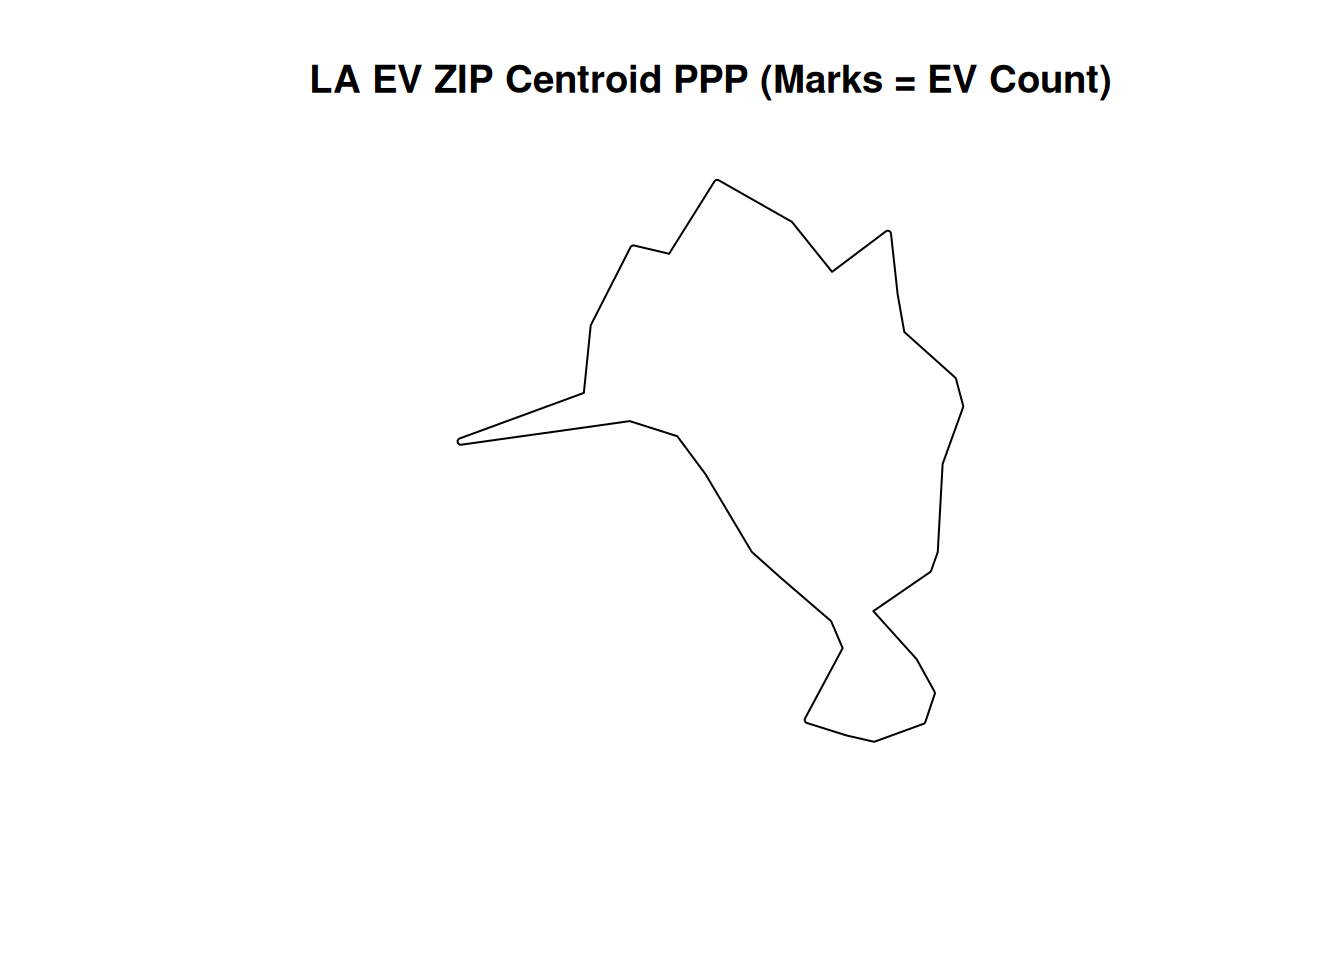

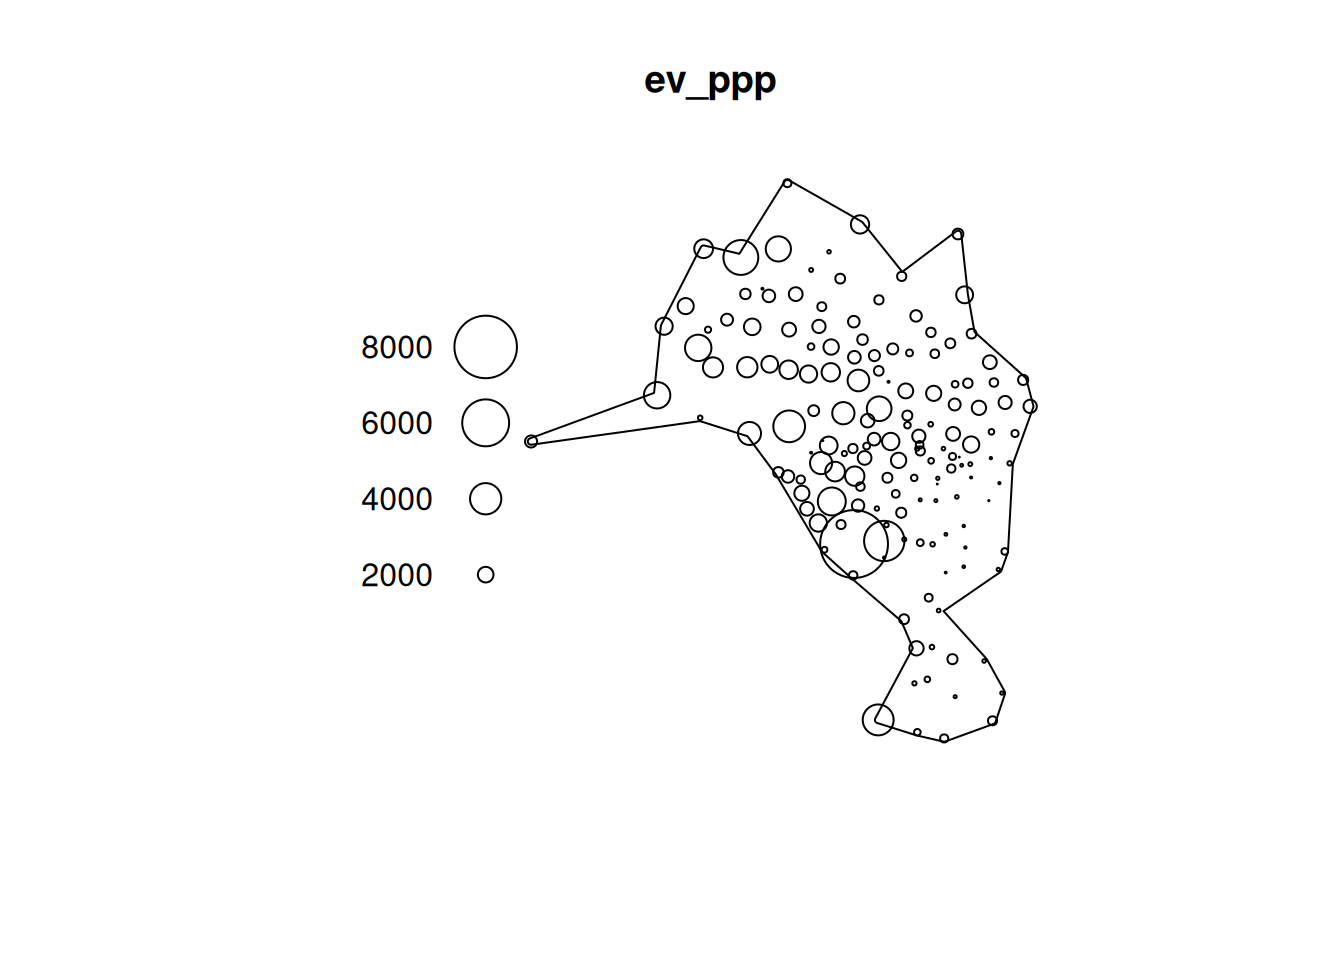

In [ ]:
zip_centroids <- zip_centroids |>
  filter(ZIP.Code != "90704") |>
  filter(ZIP.Code %in% zip_centroids$ZIP.Code)
coords <- st_coordinates(zip_centroids)
la_sfc <- la_centroids |> st_geometry()

hull_sf <- la_sfc |> 
  st_union() |> 
  sf::st_concave_hull(ratio = 0.2) |> 
  st_buffer(dist = 500)

# Convert hull polygon to spatstat window
W <- as.owin(hull_sf)

# Convert sfc POINT to ppp
ev_ppp <- ppp(
  x = coords[,1],
  y = coords[,2],
  window = W,
  marks = zip_centroids$Vehicles,
  checkdup = TRUE
)

plot(W, main = "LA EV ZIP Centroid PPP (Marks = EV Count)")

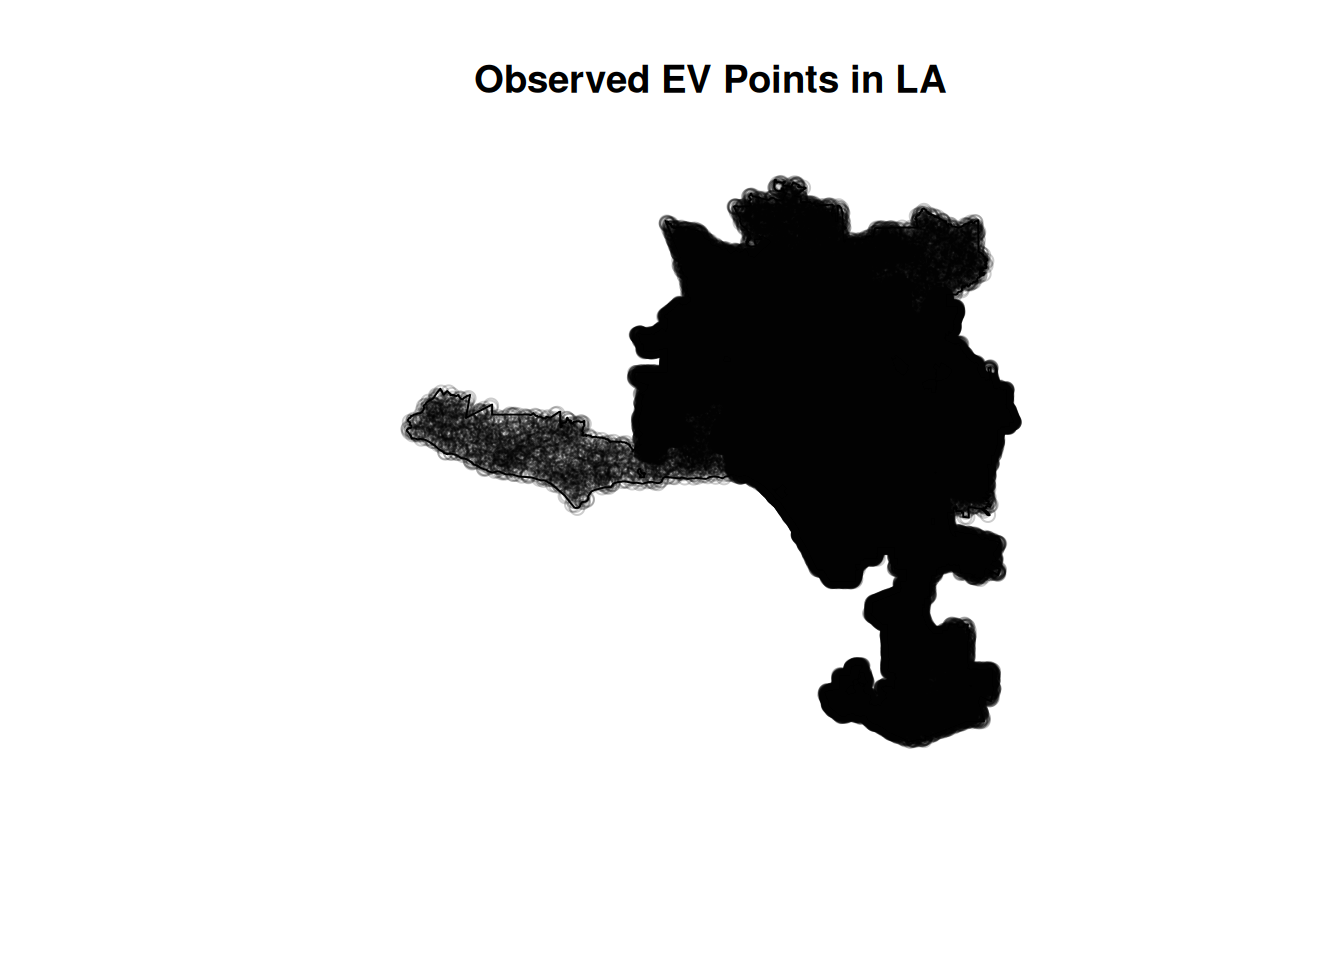

In [ ]:
# Function to generate random points within a polygon
sample_points_in_polygon <- function(polygon, n) {
  spatstat.random::rpoint(n, win = as.owin(polygon))
}

# Convert ZIP polygons to spatstat windows
la_zip_ev_sf$win <- lapply(st_geometry(la_zip_ev_sf), as.owin)

# Generate EV points for each ZIP
ev_points_list <- mapply(
  FUN = function(win, n) {
    spatstat.random::rpoint(n, win = win)
  },
  win = la_zip_ev_sf$win,
  n = la_zip_ev_sf$Vehicles,
  SIMPLIFY = FALSE
)

# Combine all PPP objects into one big PPP
ev_points <- do.call(superimpose, ev_points_list)
plot(ev_points, main = "Observed EV Points in LA")

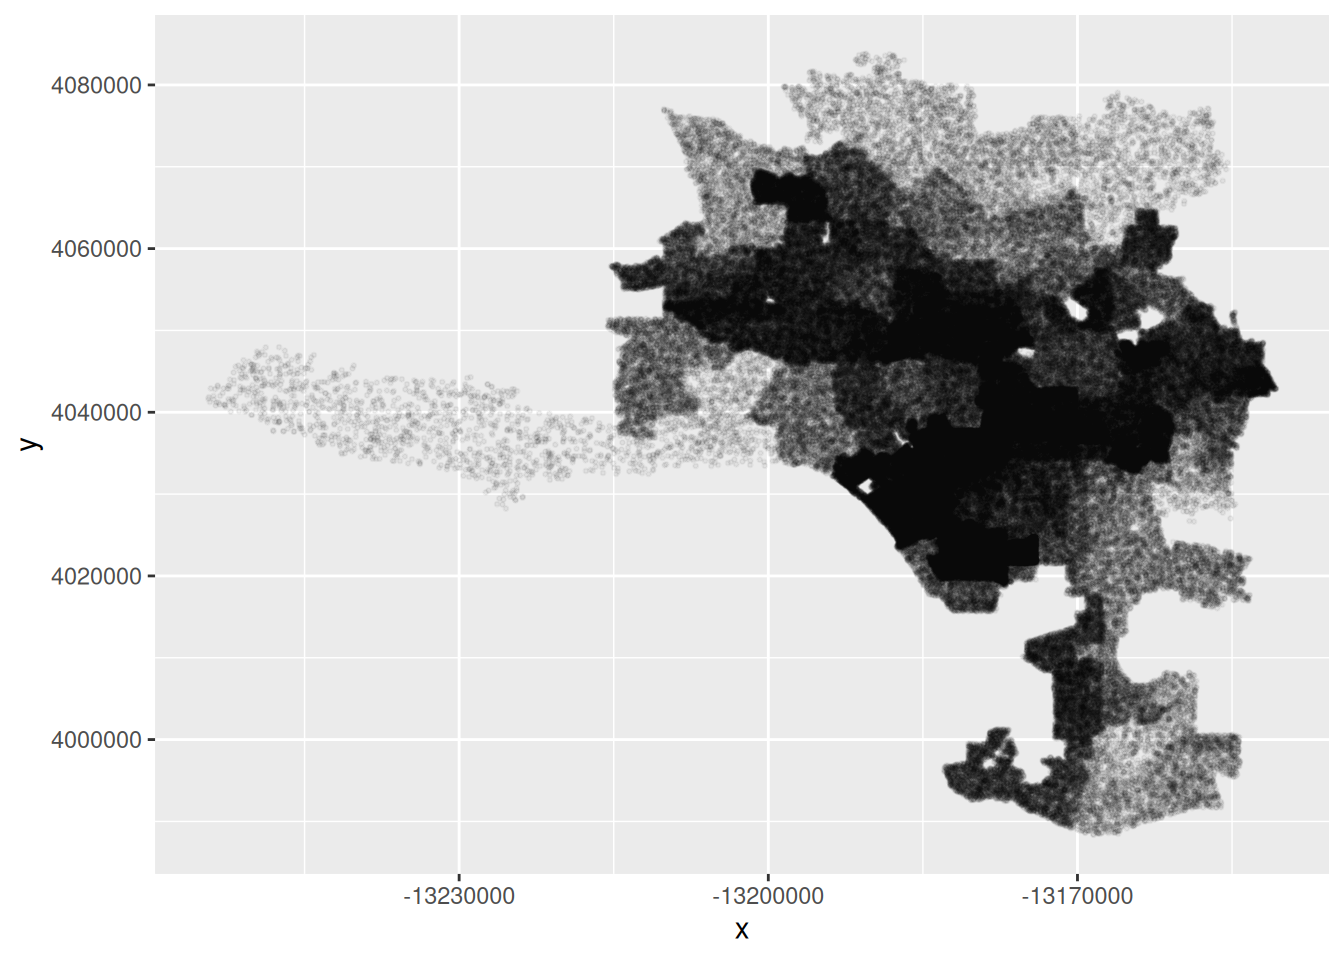

In [ ]:
ggplot(as.data.frame(ev_points), aes(x, y)) +
  geom_point(alpha = 0.05, size = 0.5)

**Unweighted EV Intensity (PPP):**

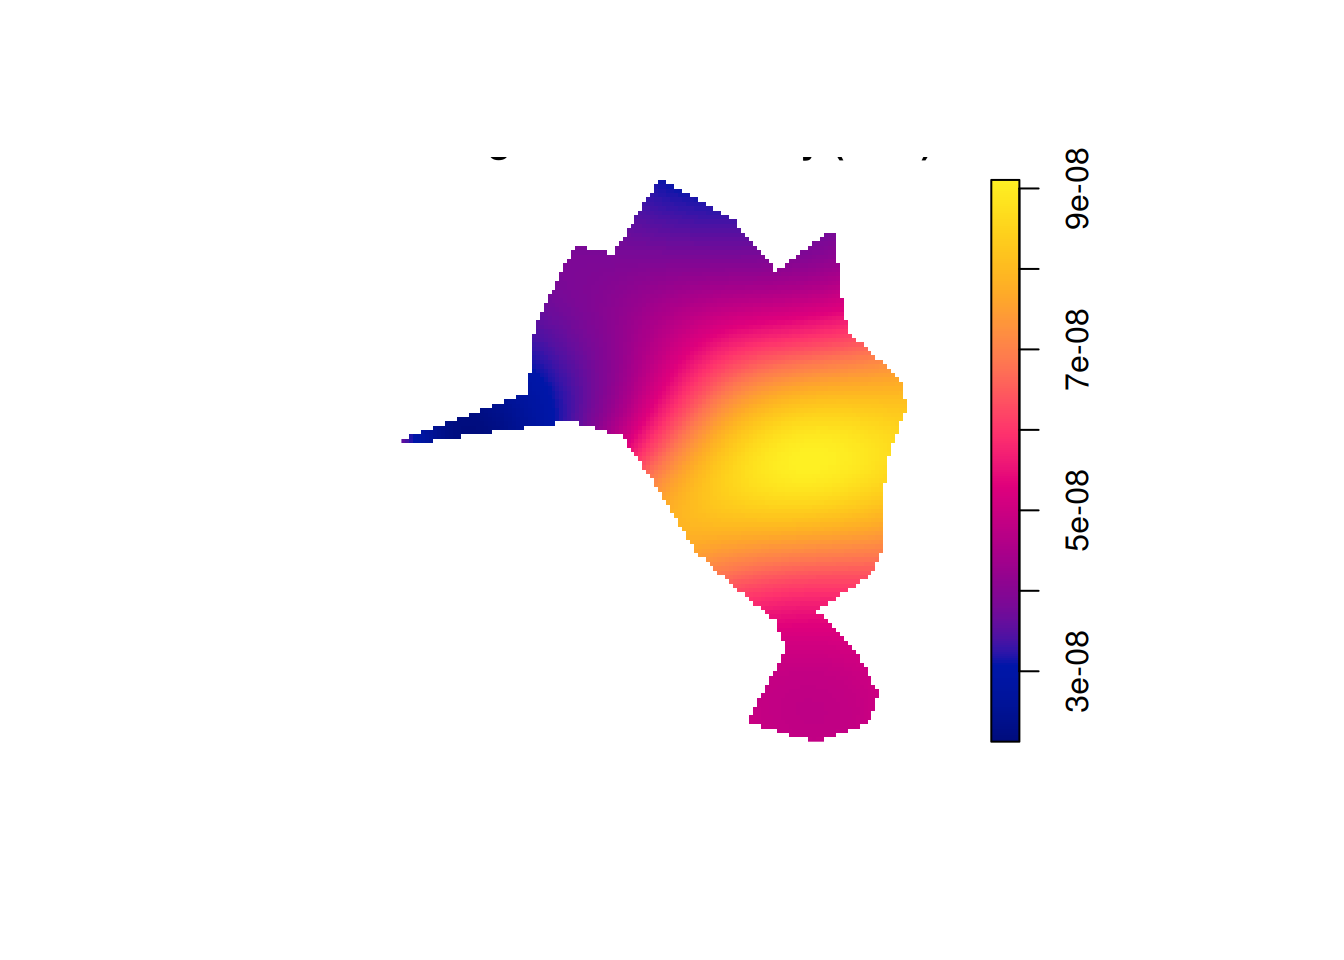

In [ ]:
# Estimated intensity functions for zip
ev_int <- density(ev_ppp)
plot(ev_int, main = "Unweighted EV Intensity (PPP)")

**EV-Weighted Intensity (Vehicles as Marks):**

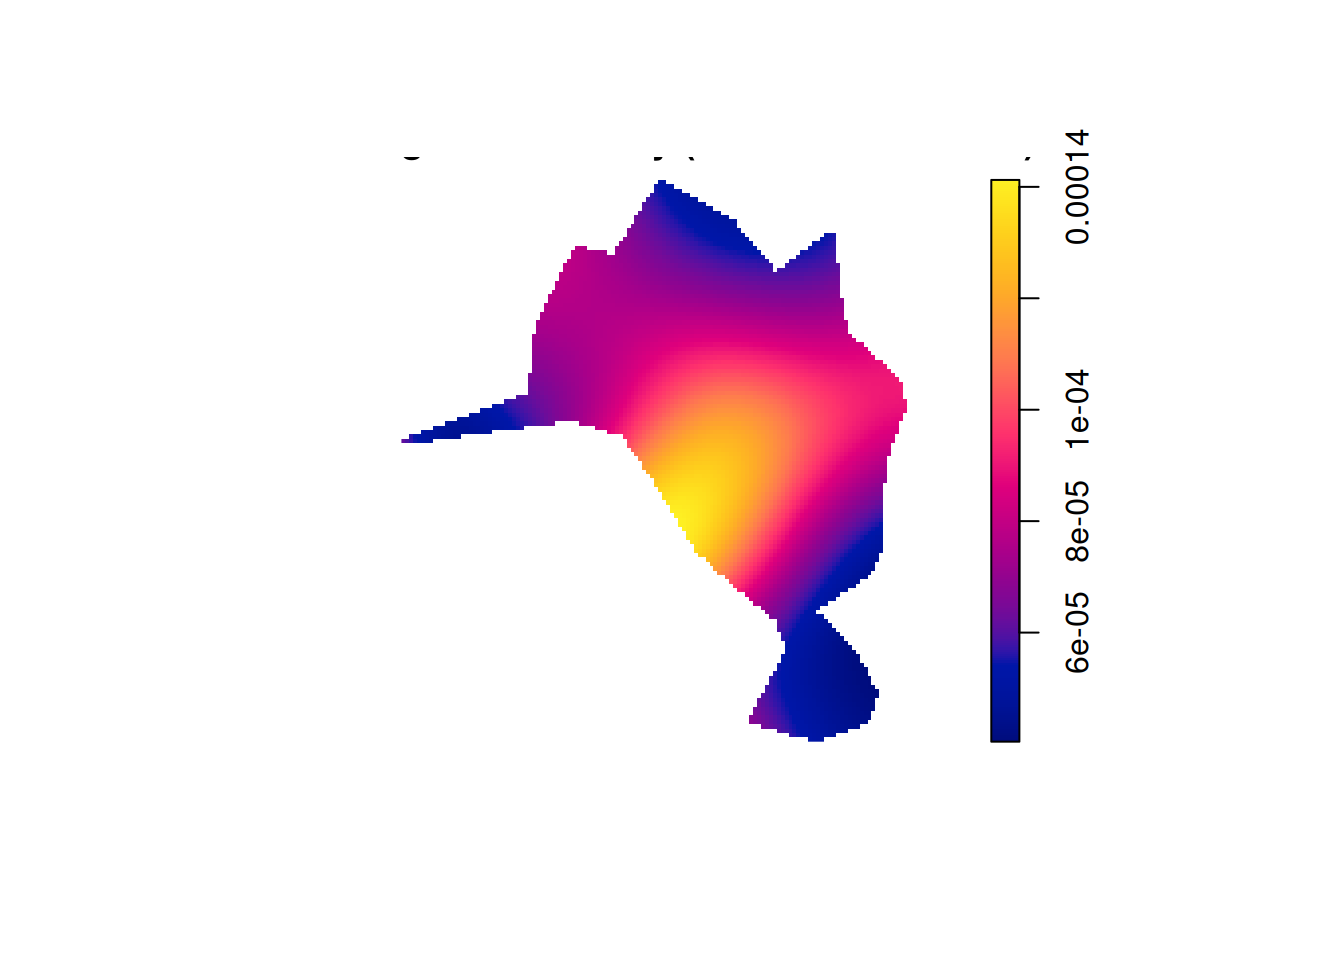

In [ ]:
# Estimated intensity functions for ev count
ev_int_w <- density(ev_ppp, weights = ev_ppp$marks)
plot(ev_int_w, main = "EV-Weighted Intensity (Vehicles as Marks)")

**Population-Weighted Intensity:**

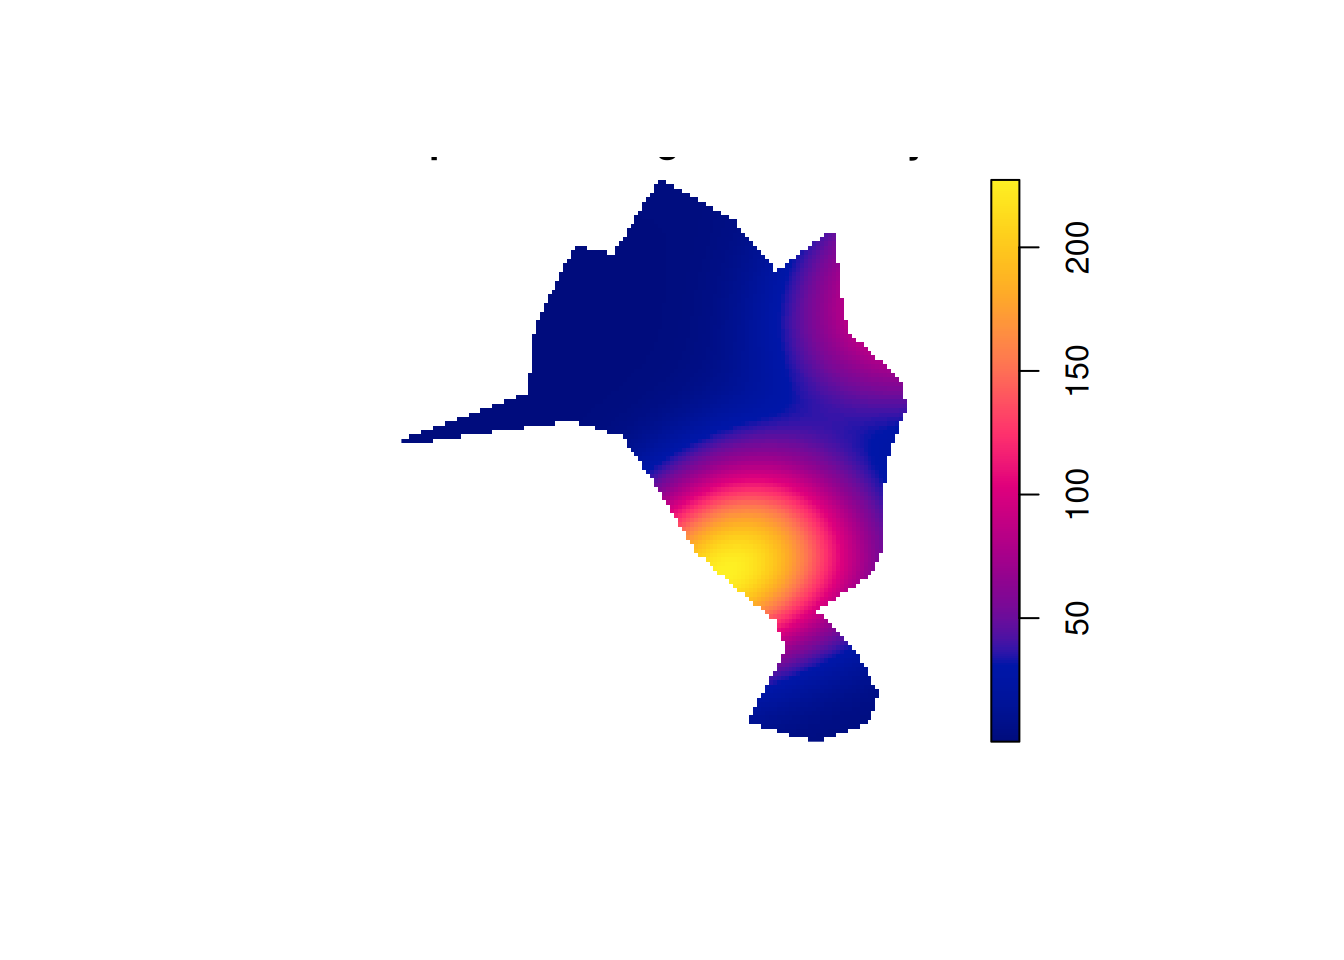

In [ ]:
# Estimated intensity functions for population
zip_centroids <- zip_centroids |> 
  left_join(df_population_la, by = "ZIP.Code") |>
  filter(!is.na(Area)) |>
  mutate(population_area = Population / Area)

coords <- st_coordinates(zip_centroids)
W <- as.owin(hull_sf)

pop_ppp <- ppp(
  x = coords[,1],
  y = coords[,2],
  window = W,
  marks = zip_centroids$population_area,
  checkdup = TRUE
)

pop_int_w <- density(pop_ppp, weights = pop_ppp$marks)
plot(pop_int_w, main = "Population-Weighted Intensity")

**Income-Weighted Intensity:**

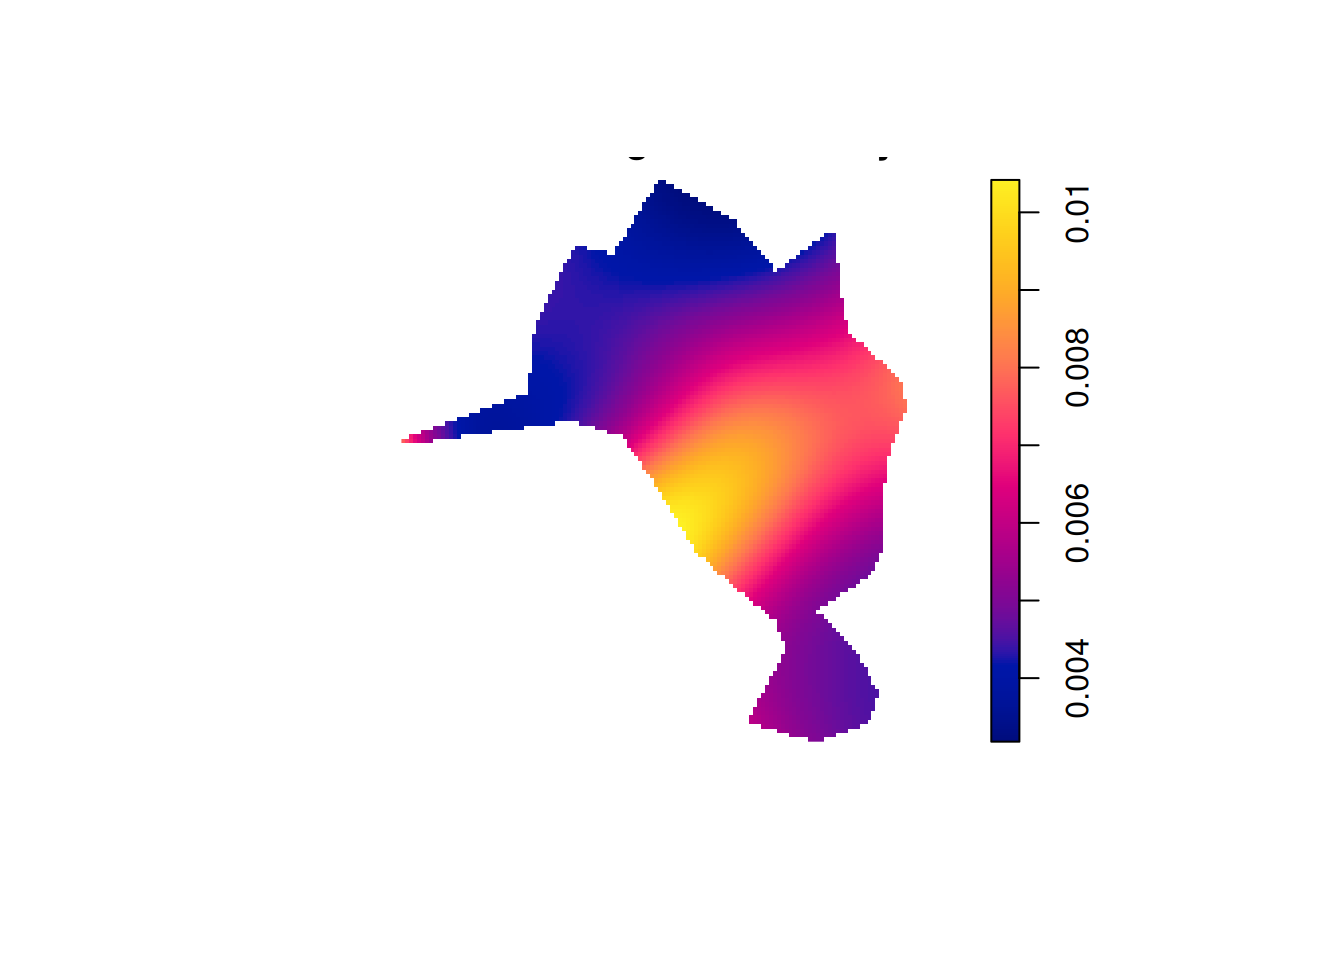

In [ ]:
# Estimated intensity functions for income
zip_inc_cleanIncome <- zip_centroids %>%
  filter(!is.na(MeanIncome))

coords <- st_coordinates(zip_inc_cleanIncome)

inc_ppp <- ppp(
  x = coords[,1],
  y = coords[,2],
  window = W,
  marks = zip_inc_cleanIncome$MeanIncome,
  checkdup = TRUE
)

inc_int_w <- density(inc_ppp, weights = inc_ppp$marks)
plot(inc_int_w, main = "Income-Weighted Intensity")

## EV counts by Population Density

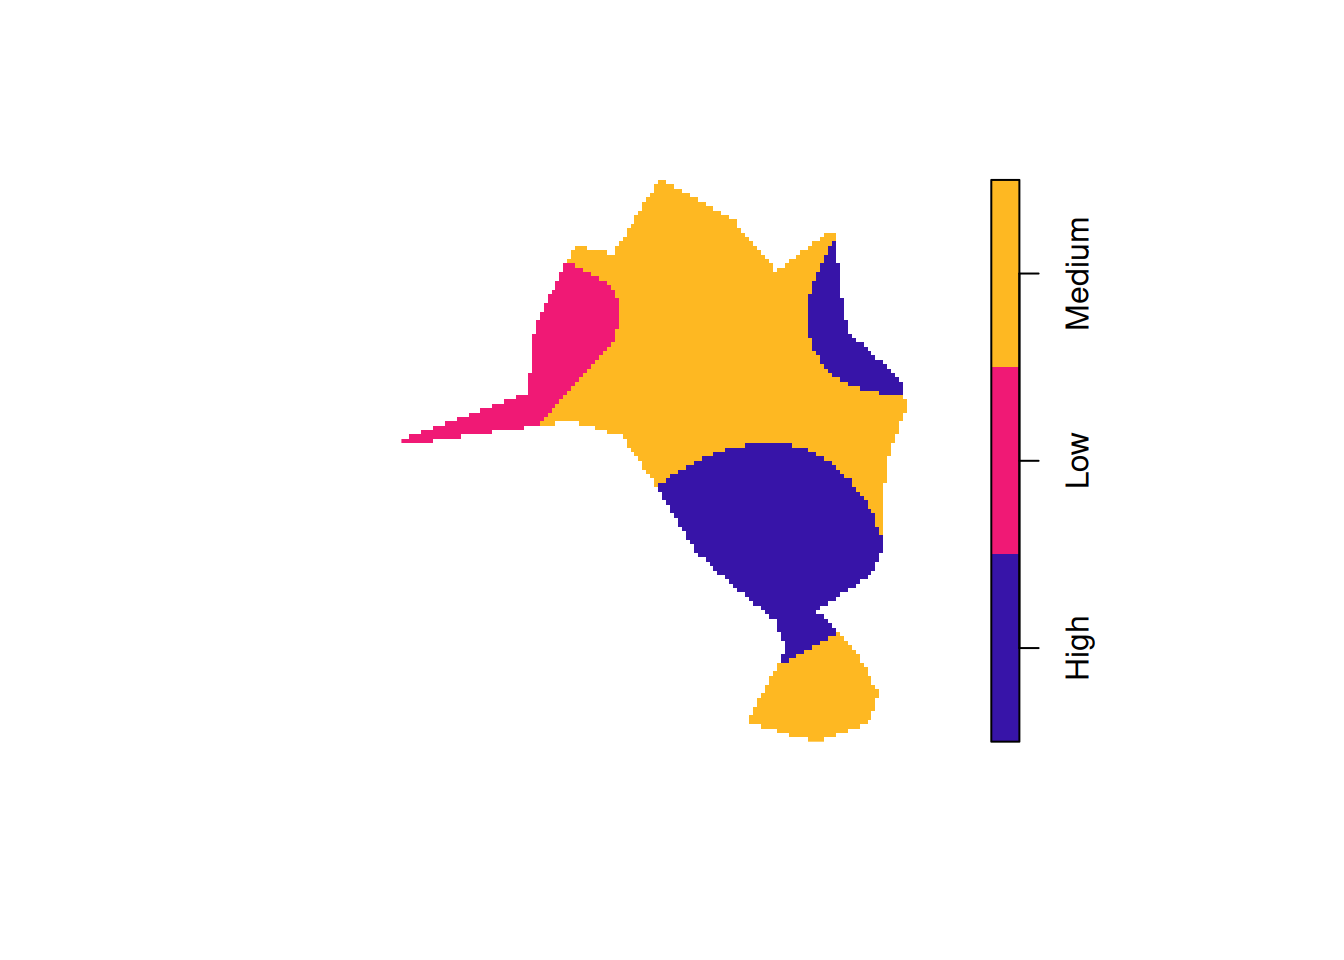

In [ ]:
num_regions <- 3
region_labels <- c("Low", "Medium", "High")

pop_vals <- pop_int_w$v  # numeric values
xcol <- pop_int_w$xcol  # x coordinates
yrow <- pop_int_w$yrow  # y coordinates
W <- pop_int_w$window

# compute split thresholds
prob_custom <- c(0, 0.10, 0.10 + 0.60, 1)  # based on U.S. Census Bureau
pop_quant <- quantile(pop_vals, probs = prob_custom, na.rm = TRUE)

# cut values into regions
pop_cut_values <- cut(
  pop_vals,
  breaks = pop_quant,
  labels = region_labels,
  include.lowest = TRUE
)

# reshape into matrix with same dimensions as original raster
pop_cut_im <- im(
  mat = matrix(pop_cut_values, nrow = nrow(pop_vals), ncol = ncol(pop_vals)),
  xcol = xcol,
  yrow = yrow,
  unitname = pop_int_w$unitname
)

pop_cut_im$window <- W

pop_areas <- tess(image = pop_cut_im)
plot(pop_areas)

## EV counts by Income Density

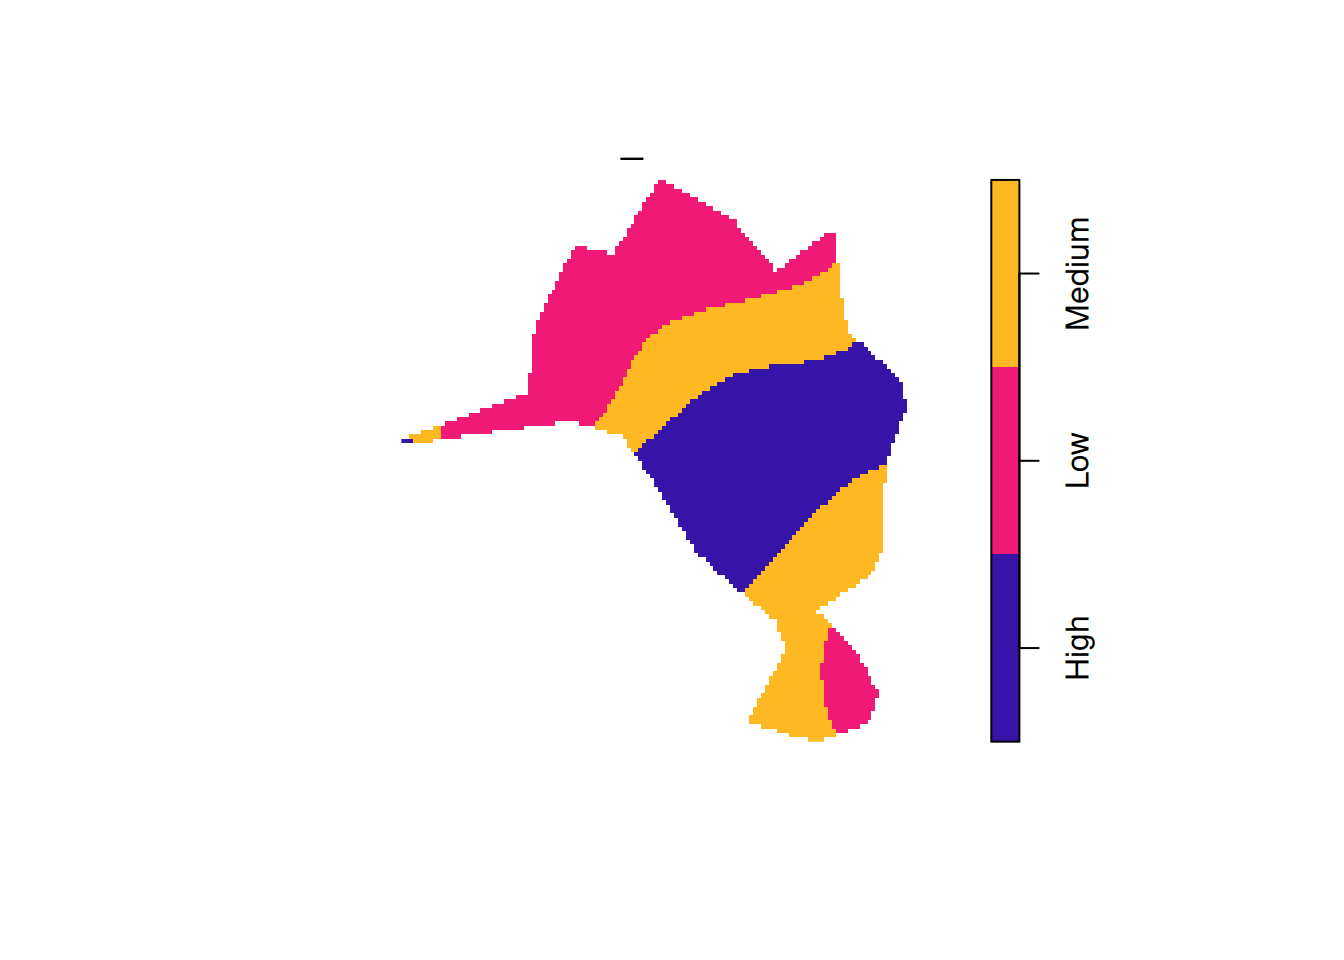

In [ ]:
num_regions <- 3
region_labels <- c("Low", "Medium", "High")

inc_vals <- inc_int_w$v  # numeric values
xcol_inc <- inc_int_w$xcol  # x coordinates
yrow_inc <- inc_int_w$yrow  # y coordinates
W_inc <- inc_int_w$window  # window

# compute split thresholds
prob_qtiles <- (0:num_regions) / num_regions
prob_custom <- c(0, 0.20, 0.20 + 0.52, 1)  # based on Pew Research Center
inc_quant <- quantile(inc_vals, probs = prob_qtiles, na.rm = TRUE)

# cut values into regions
inc_cut_values <- cut(
  inc_vals,
  breaks = inc_quant,
  labels = region_labels,
  include.lowest = TRUE
)

# reshape into an spatstat im
inc_cut_im <- im(
  mat = matrix(inc_cut_values, nrow = nrow(inc_vals), ncol = ncol(inc_vals)),
  xcol = xcol_inc,
  yrow = yrow_inc,
  unitname = inc_int_w$unitname
)

inc_cut_im$window <- W_inc

# income tessellation
inc_areas <- tess(image = inc_cut_im)
plot(inc_areas)

## Monte Carlo Simulation

In [ ]:
gen_sims_ppp <- function(num_sims) {
  ev_sims <- spatstat.random::rpoint(
    # n = nrow(zip_centroids),
    n = ev_points$n,
    f = pop_int_w,  # population intensity
    nsim = num_sims
  )
  return(ev_sims)
}

compute_quadrat_counts <- function(pp) {
  counts <- quadratcount(pp, tess = pop_areas)
  return(as.numeric(counts))
}

# real_counts <- compute_quadrat_counts(ev_ppp)
real_counts <- compute_quadrat_counts(ev_points)

Warning in quadratcount.ppp(pp, tess = pop_areas): Tessellation does not
contain all the points of X

`.name_repair` is omitted as of tibble 2.0.0.
ℹ Using compatibility `.name_repair`.

       Low   Medium    High
  -------- -------- -------
    166670       35   50040
    166258       26   50461
    166251       24   50470
    166219       30   50496
    166052       27   50666
    165698       42   51005


In [ ]:
gen_sims_inc <- function(num_sims) {
  sim_list <- spatstat.random::rpoint(
    # n = nrow(zip_centroids),
    n = ev_points$n,
    f = inc_int_w,  # income intensity
    nsim = num_sims
  )
  return(sim_list)
}

compute_inc_quadrat_counts <- function(pp) {
  counts <- quadratcount(pp, tess = inc_areas)
  as.numeric(counts)
}

# run simulations
mc_sims_inc <- 999
full_sims_inc_list <- gen_sims_inc(mc_sims_inc)

# convert to df
full_inc_sim_counts <- lapply(full_sims_inc_list, compute_inc_quadrat_counts)
full_inc_df <- full_inc_sim_counts |> do.call(rbind, args = _) |> as_tibble()
colnames(full_inc_df) <- region_labels

head(full_inc_df)

      Low   Medium    High
  ------- -------- -------
    97992    50420   68333
    97921    50638   68186
    97794    50907   68044
    97909    50483   68353
    97926    50341   68478
    98093    50864   67788


## Plotting Test Statistic Values

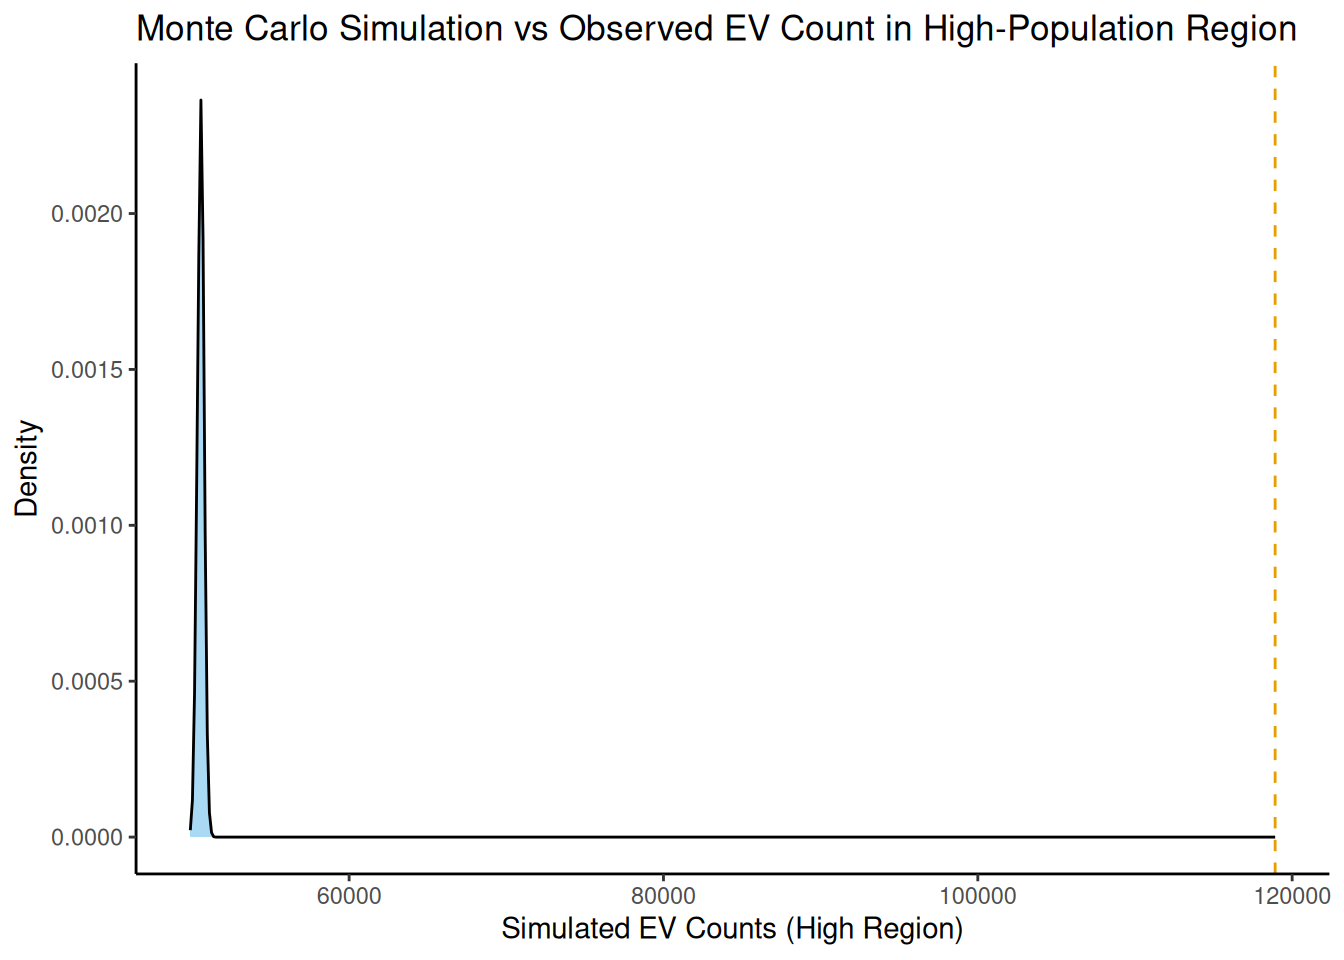

In [ ]:
# Add names to real observed counts
real_counts_named <- setNames(real_counts, region_labels)

# Convert to tibble row
obs_df <- tibble::as_tibble_row(real_counts_named)

# Combine simulated counts + observed row
mc_df <- bind_rows(full_count_df, obs_df)

# Density plot for High region
ggplot(full_count_df, aes(x = High)) +
  geom_density(fill = "#56B4E9", alpha = 0.5) +
  geom_vline(
    xintercept = obs_df$High,
    linetype = "dashed",
    color = "#E69F00"
  ) +
  theme_classic() +
  labs(
    title = "Monte Carlo Simulation vs Observed EV Count in High-Population Region",
    x = "Simulated EV Counts (High Region)",
    y = "Density"
  )

In [ ]:
more_extreme_df <- mc_df[mc_df$High >= real_counts_named["High"], ]

prop_more_extreme <- nrow(more_extreme_df) / nrow(mc_df)

prop_more_extreme

[1] 0.001

Warning in quadratcount.ppp(pp, tess = inc_areas): Tessellation does not
contain all the points of X

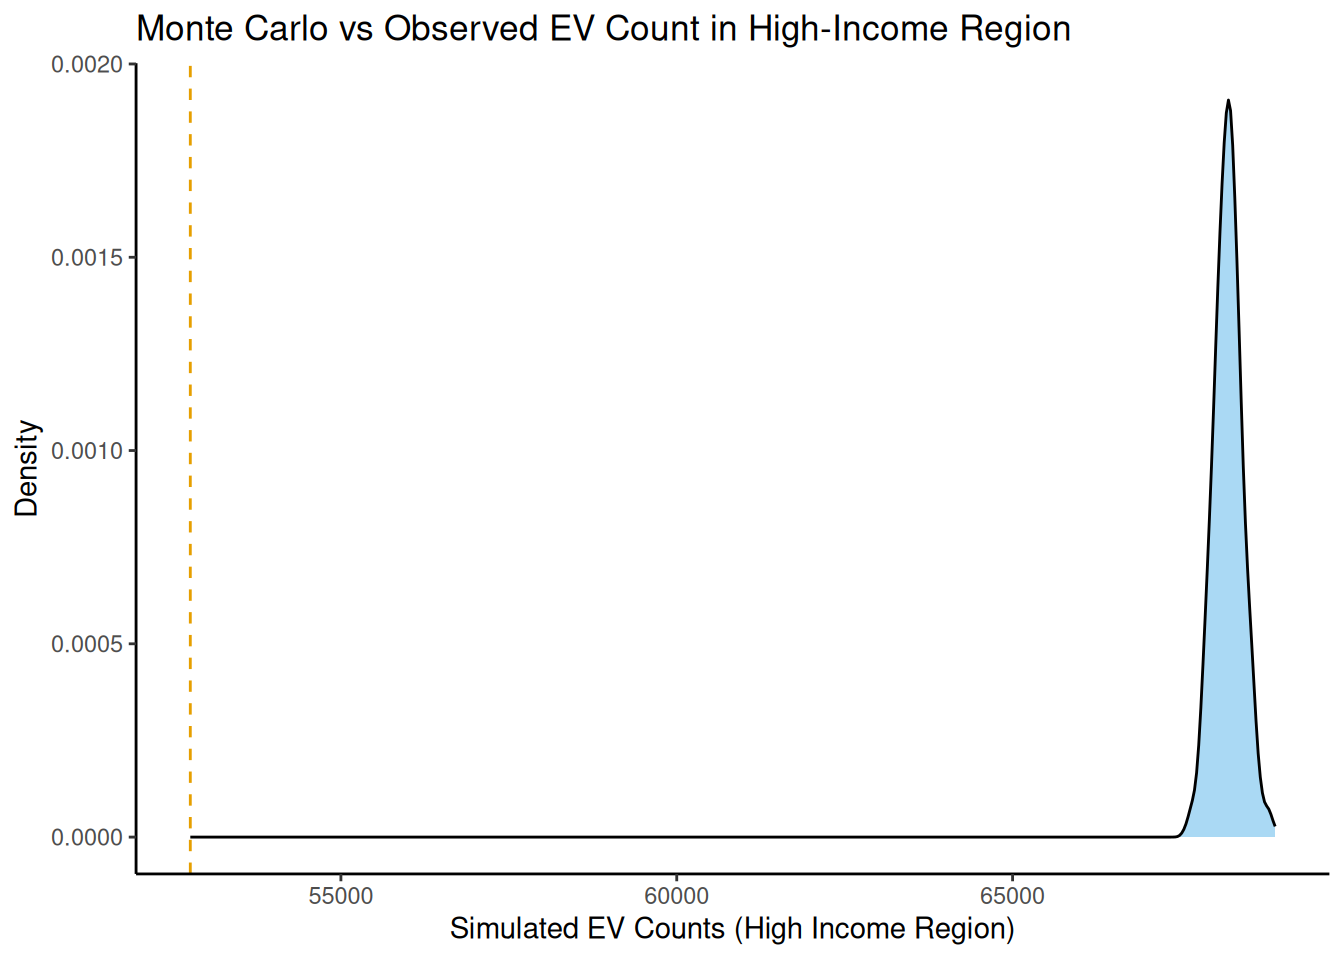

In [ ]:
# EV counts inside income regions
# real_inc_counts <- quadratcount(ev_ppp, tess = inc_areas)
# real_inc_counts <- as.numeric(real_inc_counts)
real_inc_counts <- compute_inc_quadrat_counts(ev_points)

In [ ]:
more_extreme_inc_df <- mc_inc_df[mc_inc_df$High <= real_inc_counts_named["High"], ]
prop_more_extreme_inc <- nrow(more_extreme_inc_df) / nrow(mc_inc_df)
prop_more_extreme_inc

[1] 0.001